## Previsão Aliens

<h2>Imports</h2>

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import kpss, adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error


<h2>Loading Data</h2>

In [13]:
raw_ts = pd.read_csv(
    'ufo_sightings_scrubbed.csv',
    usecols=['datetime'],
    index_col='datetime',
    parse_dates=['datetime'],
    date_format='%Y-%m-%d %H:%M:%S'
)

<h2>Transforming Data</h2>

In [14]:
ts = raw_ts.resample('ME').size()

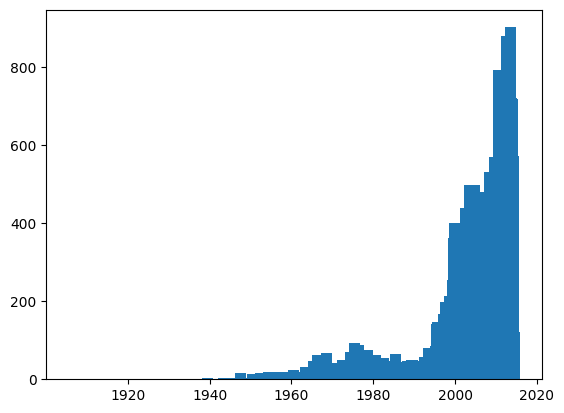

<Figure size 6400x800 with 0 Axes>

In [15]:
plt.bar(ts.index, ts.values, width=1000)
plt.figure(figsize=(64,8))
plt.show()

## ACF e PACF

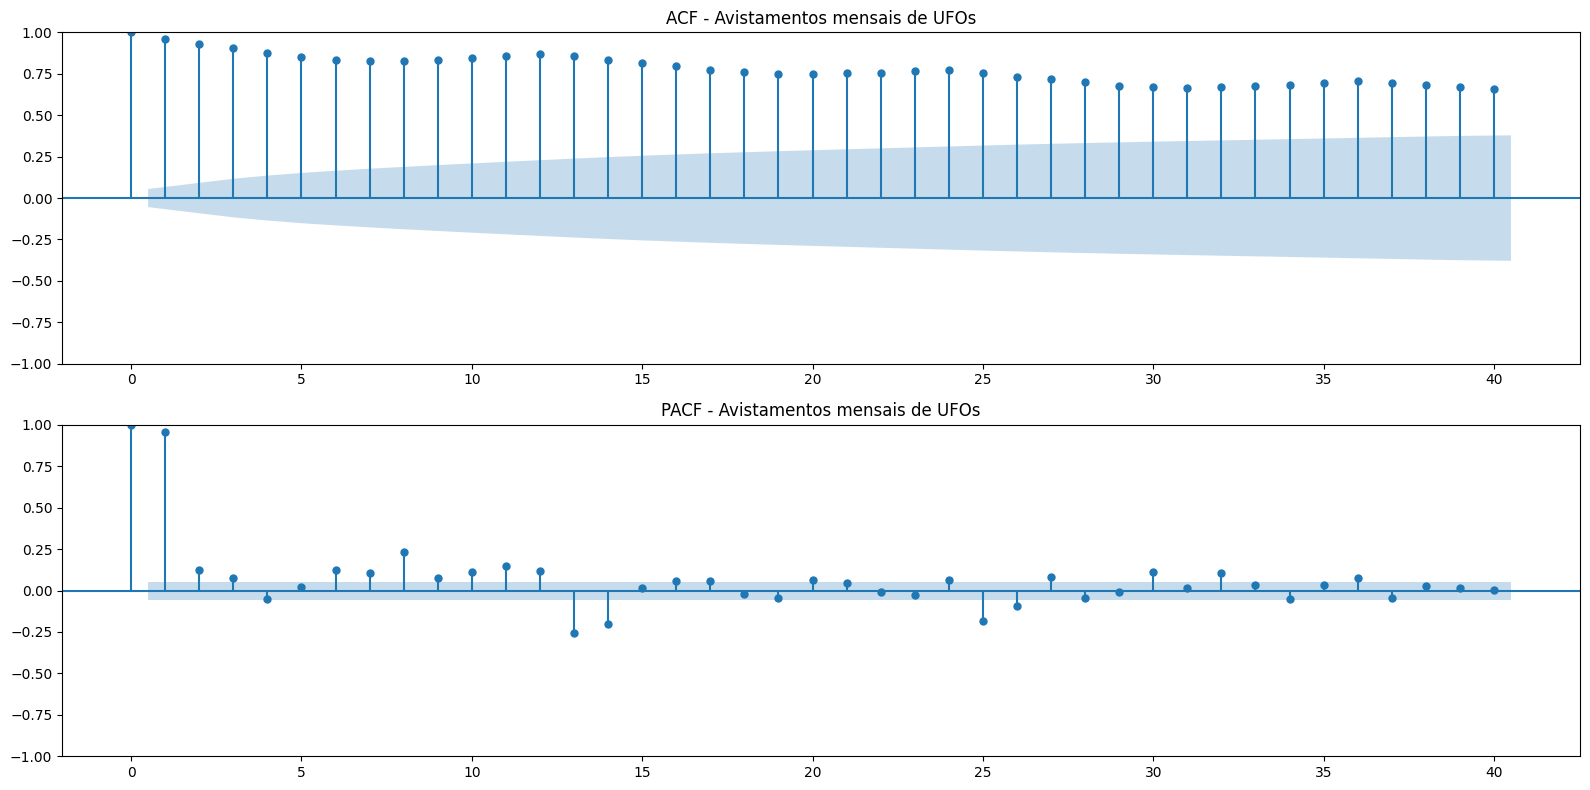

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

plot_acf(ts, lags=40, ax=axes[0], title='ACF - Avistamentos mensais de UFOs')
plot_pacf(ts, lags=40, ax=axes[1], title='PACF - Avistamentos mensais de UFOs')

plt.tight_layout()
plt.show()

# Decomposição STL

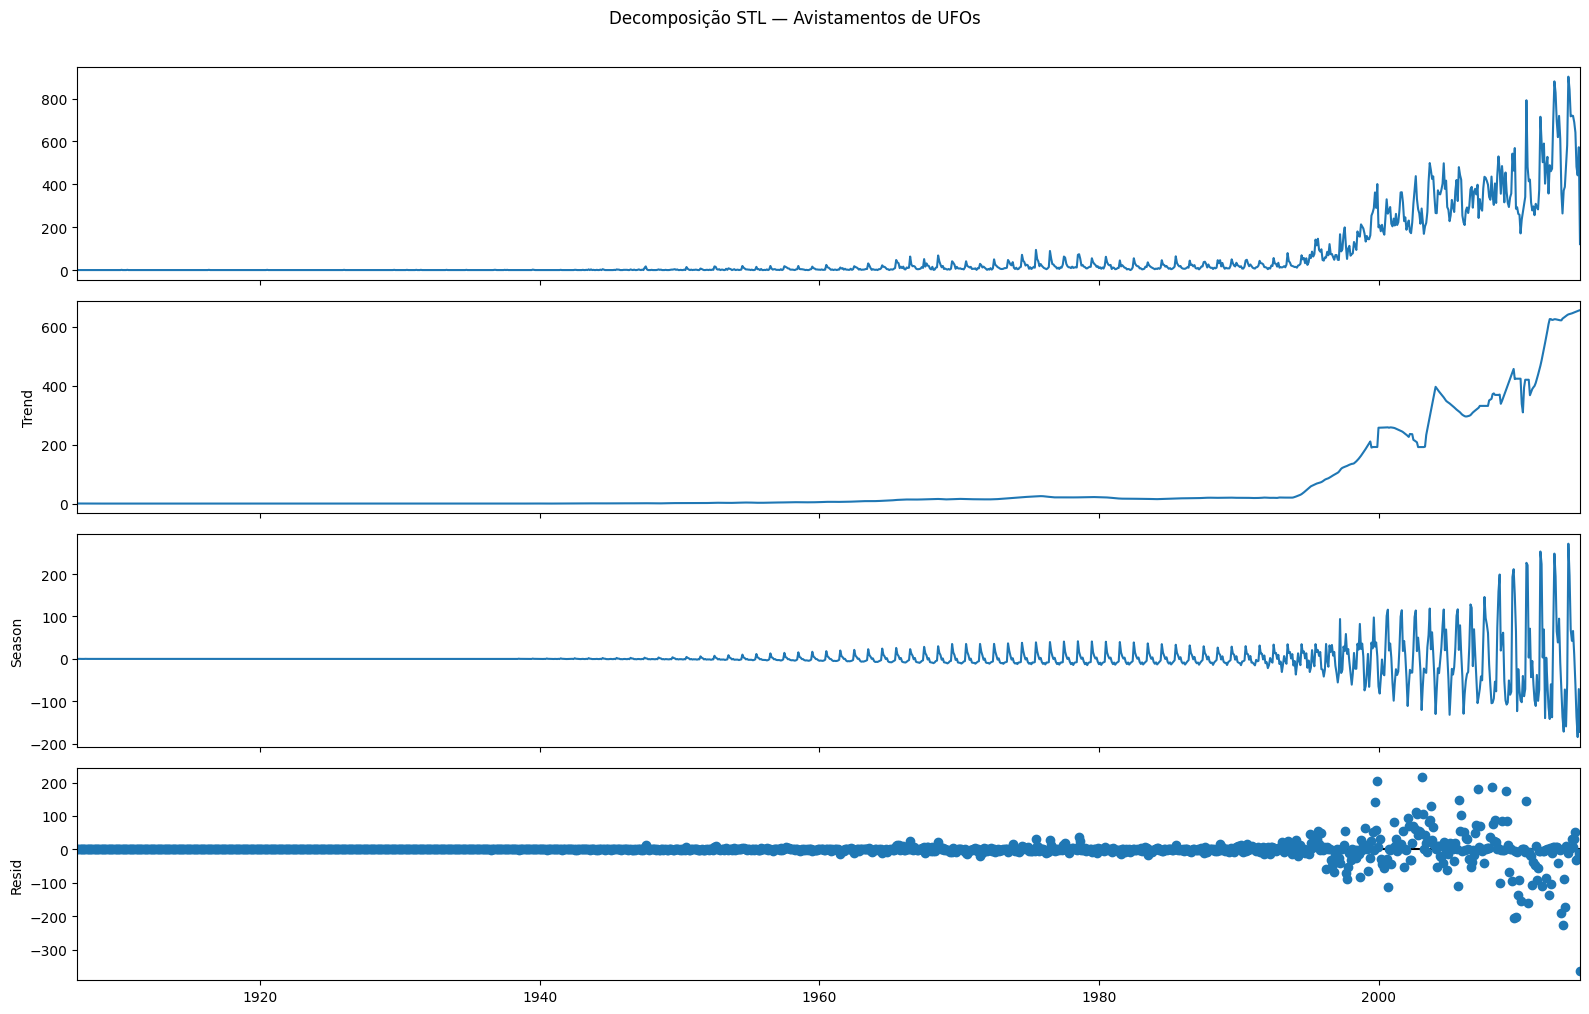

In [17]:
stl = STL(ts, period=12, seasonal=13, robust=True)
result = stl.fit()

fig = result.plot()
fig.set_size_inches(16, 10)
fig.suptitle('Decomposição STL — Avistamentos de UFOs', y=1.01)
plt.tight_layout()
plt.show()

In [18]:
trend, seasonal, resid = result.trend, result.seasonal, result.resid

F_trend = max(0, 1 - resid.var() / (trend + resid).var())
F_seasonal = max(0, 1 - resid.var() / (seasonal + resid).var())

print(f'Força de tendência   (F_T): {F_trend:.3f}')
print(f'Força de sazonalidade (F_S): {F_seasonal:.3f}')

Força de tendência   (F_T): 0.954
Força de sazonalidade (F_S): 0.582


# ADF

In [19]:
adf_ts = adfuller(ts.dropna())

print("Estatística ADF:", adf_ts[0])
print("p-valor:", adf_ts[1])
print("Valores críticos:", adf_ts[4])

Estatística ADF: 4.26690711163635
p-valor: 1.0
Valores críticos: {'1%': np.float64(-3.4355217427788793), '5%': np.float64(-2.8638238726872296), '10%': np.float64(-2.5679859566283705)}


# KPSS

In [20]:
kpss_ts = kpss(ts.dropna(), regression='c', nlags='auto')

print("KPSS Estatística:", kpss_ts[0])
print("p-valor:", kpss_ts[1])
print("Valores críticos:", kpss_ts[3])

KPSS Estatística: 3.009411799789264
p-valor: 0.01
Valores críticos: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\sophiaragusa-ieg\AppData\Local\Temp\ipykernel_31800\2451046276.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_ts = kpss(ts.dropna(), regression='c', nlags='auto')


# SARIMA


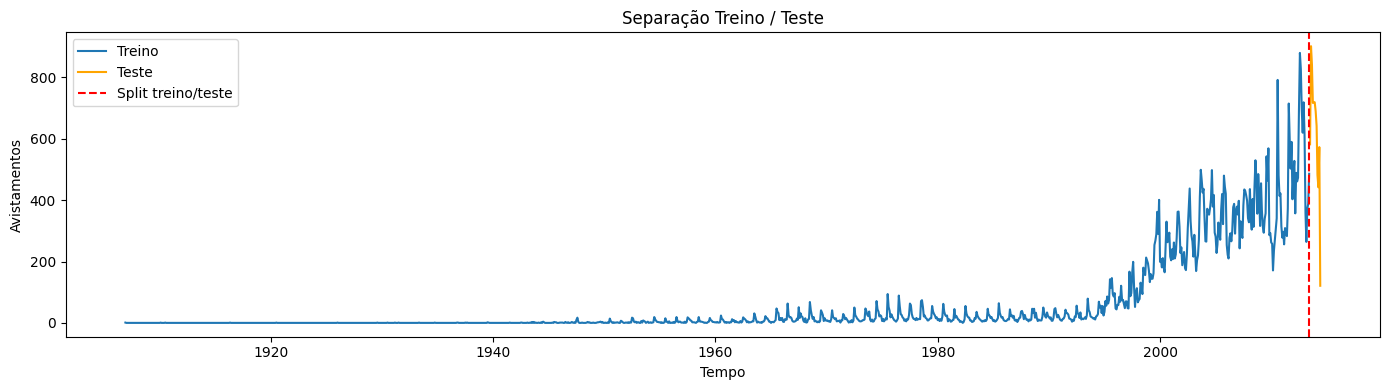

Treino: 1279 observações (1906-11-30 → 2013-05-31)
Teste:  12 observações (2013-06-30 → 2014-05-31)


In [21]:
h = 12  # horizonte de previsão: 12 meses
treino = ts[:-h]
teste = ts[-h:]

plt.figure(figsize=(14, 4))
plt.plot(treino.index, treino.values, label='Treino')
plt.plot(teste.index, teste.values, label='Teste', color='orange')
plt.axvline(treino.index[-1], ls='--', color='red', label='Split treino/teste')
plt.xlabel('Tempo')
plt.ylabel('Avistamentos')
plt.title('Separação Treino / Teste')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Treino: {len(treino)} observações ({treino.index[0].date()} → {treino.index[-1].date()})')
print(f'Teste:  {len(teste)} observações ({teste.index[0].date()} → {teste.index[-1].date()})')

In [22]:
s = 12  # sazonalidade mensal anual

resultados = []

for p in range(0, 3):
    for d in range(0, 2):
        for q in range(0, 3):
            for P in range(0, 2):
                for D in range(0, 2):
                    for Q in range(0, 2):
                        if p == 0 and d == 0 and q == 0 and P == 0 and D == 0 and Q == 0:
                            continue
                        try:
                            modelo = SARIMAX(
                                treino,
                                order=(p, d, q),
                                seasonal_order=(P, D, Q, s),
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            ).fit(disp=False)
                            resultados.append({
                                'ordem': (p, d, q),
                                'ordem_sazonal': (P, D, Q, s),
                                'AIC': float(modelo.aic),
                                'BIC': float(modelo.bic),
                                'modelo': modelo
                            })
                        except Exception:
                            continue

# Ordenar por BIC e pegar top 10
resultados = sorted(resultados, key=lambda x: x['BIC'])
top10 = resultados[:10]

# Exibir tabela
print(f"{'#':<4} {'Ordem':<15} {'Sazonal':<18} {'AIC':>12} {'BIC':>12}")
print("-" * 63)
for i, r in enumerate(top10):
    print(f"{i+1:<4} {str(r['ordem']):<15} {str(r['ordem_sazonal']):<18} {r['AIC']:>12.2f} {r['BIC']:>12.2f}")

# Melhor modelo continua sendo o de menor BIC
melhor = top10[0]
melhor_ordem = melhor['ordem']
melhor_ordem_sazonal = melhor['ordem_sazonal']
melhor_modelo = melhor['modelo']

C:\Users\sophiaragusa-ieg\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\sophiaragusa-ieg\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


#    Ordem           Sazonal                     AIC          BIC
---------------------------------------------------------------
1    (1, 1, 2)       (0, 1, 1, 12)          11893.47     11919.13
2    (1, 1, 2)       (1, 1, 1, 12)          11895.34     11926.13
3    (2, 1, 2)       (0, 1, 1, 12)          11895.43     11926.22
4    (2, 1, 2)       (1, 1, 1, 12)          11897.30     11933.22
5    (2, 1, 1)       (0, 1, 1, 12)          11908.68     11934.35
6    (2, 1, 1)       (1, 1, 1, 12)          11910.64     11941.44
7    (1, 1, 1)       (0, 1, 1, 12)          11923.07     11943.60
8    (1, 0, 2)       (0, 1, 1, 12)          11924.86     11950.52
9    (1, 1, 1)       (1, 1, 1, 12)          11925.06     11950.72
10   (0, 1, 2)       (0, 1, 1, 12)          11930.23     11950.76


C:\Users\sophiaragusa-ieg\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [23]:
print(melhor_modelo.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                 1279
Model:             SARIMAX(1, 1, 2)x(0, 1, [1], 12)   Log Likelihood               -5941.734
Date:                              Sat, 23 May 2026   AIC                          11893.467
Time:                                      13:21:49   BIC                          11919.126
Sample:                                  11-30-1906   HQIC                         11903.113
                                       - 05-31-2013                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7816      0.020     39.743      0.000       0.743       0.820
ma.L1         -1.33

In [24]:
fc = melhor_modelo.get_forecast(steps=h)
mean = fc.predicted_mean
ci = fc.conf_int(alpha=0.05)

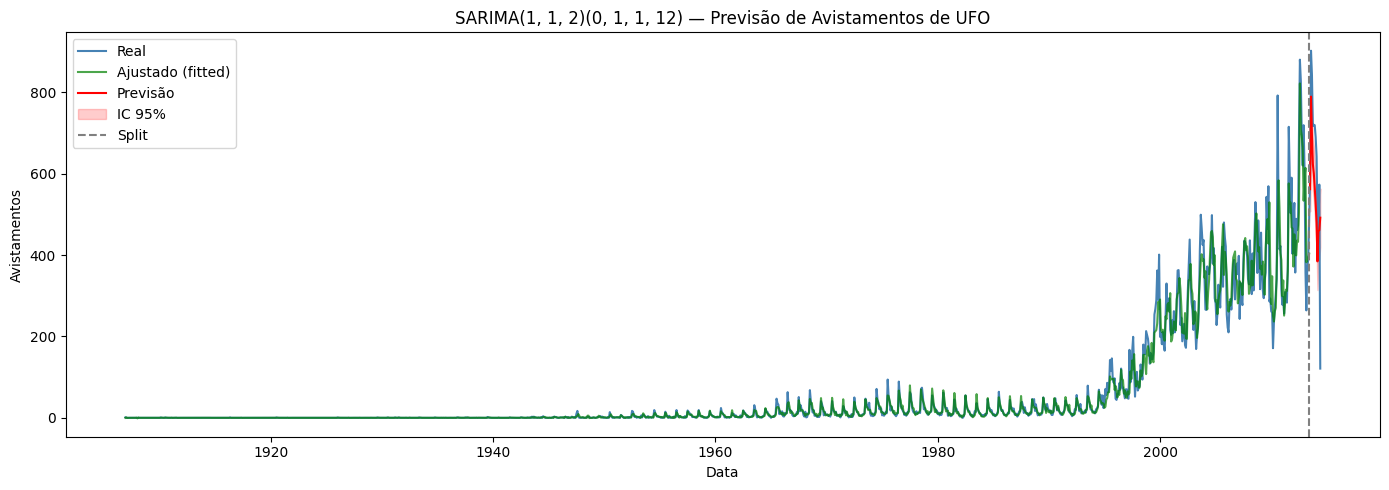

y                 mean    mean_se  mean_ci_lower  mean_ci_upper
2013-06-30  561.778493  27.898522     507.098395     616.458592
2013-07-31  789.180835  30.586288     729.232813     849.128857
2013-08-31  692.496460  32.310638     629.168773     755.824146
2013-09-30  623.330098  33.475651     557.719027     688.941169
2013-10-31  600.818239  34.296218     533.598887     668.037592
2013-11-30  566.224529  34.896241     497.829153     634.619905
2013-12-31  526.504799  35.350815     457.218476     595.791123
2014-01-31  479.120013  35.707082     409.135418     549.104607
2014-02-28  384.370035  35.995469     313.820213     454.919858
2014-03-31  458.740782  36.236081     387.719368     529.762196
2014-04-30  460.863735  36.442486     389.437775     532.289696
2014-05-31  491.717408  36.624018     419.935651     563.499164


In [25]:
fitted = melhor_modelo.fittedvalues
x_ci = ci.index.to_pydatetime()

plt.figure(figsize=(14, 5))
plt.plot(ts.index, ts.values, label='Real', color='steelblue')
plt.plot(fitted.index, fitted.values, label='Ajustado (fitted)', color='green', alpha=0.7)
plt.plot(mean.index, mean.values, label='Previsão', color='red')
plt.fill_between(x_ci, ci.iloc[:, 0].values, ci.iloc[:, 1].values, alpha=0.2, color='red', label='IC 95%')
plt.axvline(treino.index[-1], ls='--', color='gray', label='Split')
plt.xlabel('Data')
plt.ylabel('Avistamentos')
plt.title(f'SARIMA{melhor_ordem}{melhor_ordem_sazonal} — Previsão de Avistamentos de UFO')
plt.legend()
plt.tight_layout()
plt.show()

print(fc.summary_frame())

In [26]:
mae = mean_absolute_error(teste.values, mean.values)
print(f'MAE (Erro Absoluto Médio) no teste: {mae:.2f} avistamentos/mês')

MAE (Erro Absoluto Médio) no teste: 130.98 avistamentos/mês
